In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

#### Load dataset

In [2]:


df = pd.read_csv("2024_Annual_Punctuality_Statistics_Full_Analysis_Arrival_Departure.csv")

df.head()

,run_date,reporting_period,reporting_airport,origin_destination_country,origin_destination,airline_name,arrival_departure,scheduled_charter,number_flights_matched,actual_flights_unmatched,...,flights_between_61_and_120_minutes_late_percent,flights_between_121_and_180_minutes_late_percent,flights_between_181_and_360_minutes_late_percent,flights_more_than_360_minutes_late_percent,flights_unmatched_percent,flights_cancelled_percent,average_delay_mins,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay
0,14/03/2025 12:26,2024,ABERDEEN,CANADA,TORONTO,TUI AIRWAYS LTD,D,S,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,1,0.000000,44.0
1,14/03/2025 12:26,2024,ABERDEEN,AZERBAIJAN,BAKU (HEYDER ALIYEV INT'L),AIR HAMBURG,A,C,1,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.000000,NaN
2,14/03/2025 12:26,2024,ABERDEEN,BULGARIA,BURGAS,BH AIR,A,C,13,0,...,7.692308,0.000000,0.000000,0.0,0.0,0.0,13.0,13,76.923077,11.0
3,14/03/2025 12:26,2024,ABERDEEN,BULGARIA,BURGAS,BH AIR,D,C,13,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,21.0,13,69.230769,13.0
4,14/03/2025 12:26,2024,ABERDEEN,LATVIA,RIGA,AIR BALTIC,A,S,33,0,...,18.181818,3.030303,3.030303,0.0,0.0,0.0,35.0,34,61.764706,24.0


#### Dataset Overview

In [3]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13013 entries, 0 to 13012
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   run_date                                            13013 non-null  object 
 1   reporting_period                                    13013 non-null  int64  
 2   reporting_airport                                   13013 non-null  object 
 3   origin_destination_country                          13013 non-null  object 
 4   origin_destination                                  13013 non-null  object 
 5   airline_name                                        13013 non-null  object 
 6   arrival_departure                                   13013 non-null  object 
 7   scheduled_charter                                   13013 non-null  object 
 8   number_flights_matched                              13013 non-null  int64  


#### Check Missing Values

In [4]:
df.isnull().sum()

,0
run_date,0
reporting_period,0
reporting_airport,0
origin_destination_country,0
origin_destination,0
airline_name,0
arrival_departure,0
scheduled_charter,0
number_flights_matched,0
actual_flights_unmatched,0


#### Descriptive Statistics

In [5]:
df.describe()

,reporting_period,number_flights_matched,actual_flights_unmatched,number_flights_cancelled,flights_more_than_15_minutes_early_percent,flights_15_minutes_early_to_1_minute_early_percent,flights_0_to_15_minutes_late_percent,flights_between_16_and_30_minutes_late_percent,flights_between_31_and_60_minutes_late_percent,flights_between_61_and_120_minutes_late_percent,flights_between_121_and_180_minutes_late_percent,flights_between_181_and_360_minutes_late_percent,flights_more_than_360_minutes_late_percent,flights_unmatched_percent,flights_cancelled_percent,average_delay_mins,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay
count,13013.0,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,13013.000000,9999.000000,13013.000000,13013.000000,9792.000000
mean,2024.0,144.416737,0.029893,2.087144,4.355113,17.977297,24.426612,11.625271,9.645636,5.431989,1.382415,0.762599,0.239752,0.171977,3.684441,24.457446,137.591870,44.438824,26.229575
std,0.0,332.891831,0.222361,8.485368,12.253549,21.991473,25.681208,18.615834,17.275778,13.448899,7.167504,5.712592,3.394585,3.804229,17.208431,41.487991,317.498468,36.147562,40.312770
min,2024.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,1.000000,0.000000,12.000000
50%,2024.0,17.000000,0.000000,0.000000,0.000000,11.764706,23.098592,7.368421,4.545455,1.149425,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,17.000000,51.992410,20.000000
75%,2024.0,132.000000,0.000000,1.000000,1.960784,30.000000,37.804878,15.825375,12.626263,6.113537,1.130319,0.237530,0.000000,0.000000,0.184672,28.000000,120.000000,73.750000,30.000000
max,2024.0,4317.000000,8.000000,166.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1382.000000,3992.000000,100.000000,1305.000000


#### Distribution of Average Delay

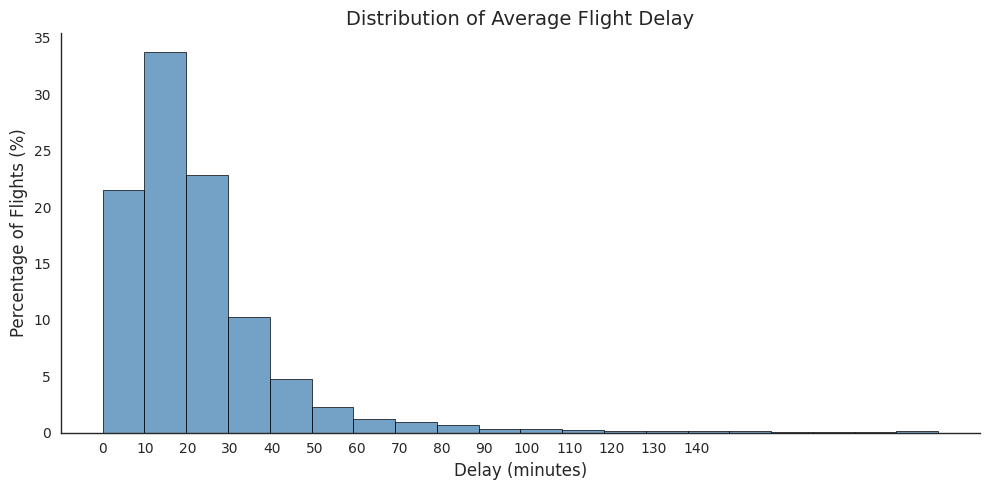

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

data = df["average_delay_mins"]
data = data[data <= 200]

plt.figure(figsize=(10,5))

sns.histplot(
    data,
    bins=20,
    stat="percent",
    color="steelblue",
    edgecolor="black"
)

plt.xticks(np.arange(0,150, 10))

plt.title("Distribution of Average Flight Delay", fontsize=14)

plt.xlabel("Delay (minutes)")
plt.ylabel("Percentage of Flights (%)")

sns.despine()
plt.tight_layout()
plt.savefig("Distribution of Average Delay.png",dpi = 300)
plt.show()

#### Airport Performance Analysis

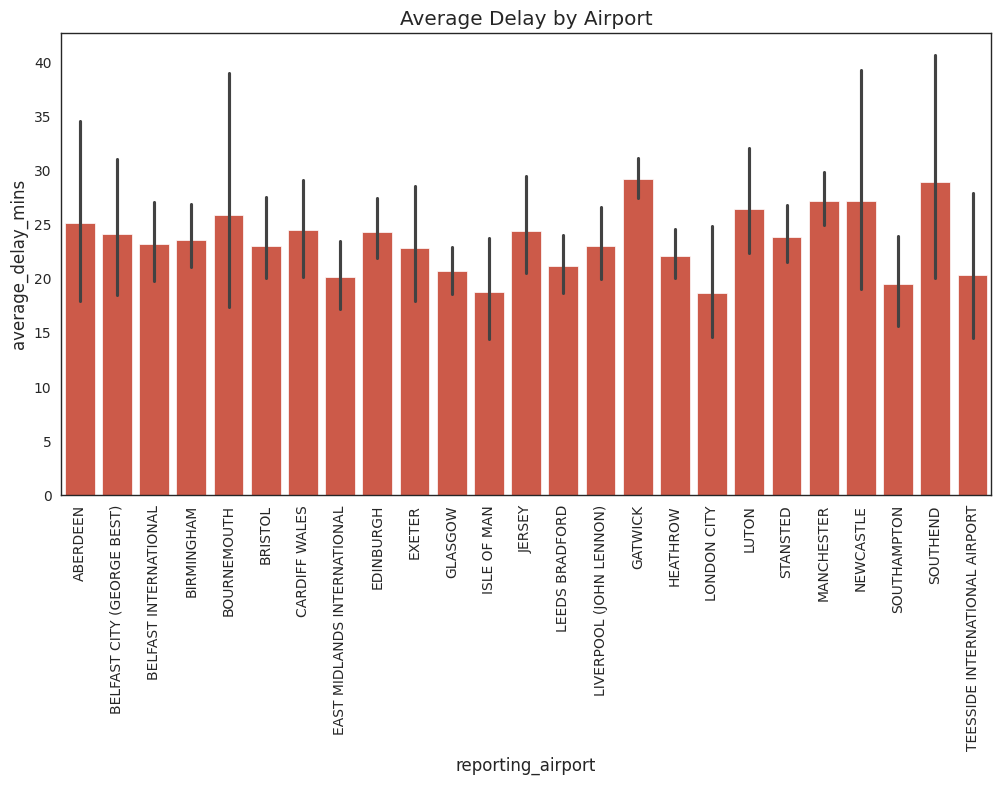

In [7]:
plt.figure(figsize=(12,6))
sns.barplot(x="reporting_airport", y="average_delay_mins", data=df)
plt.xticks(rotation=90)
plt.title("Average Delay by Airport")
plt.savefig("airport_performance.png",dpi = 300)
plt.show()

#### Arrival vs Departure Delays

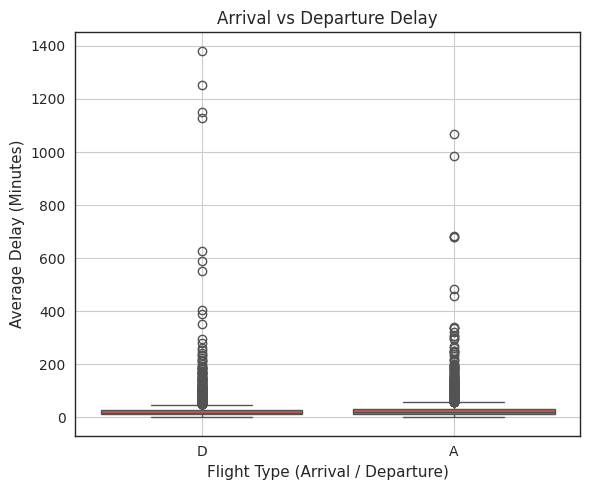

In [8]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="arrival_departure",
    y="average_delay_mins",
    data=df
)

plt.title("Arrival vs Departure Delay", fontsize=12)

plt.xlabel("Flight Type (Arrival / Departure)", fontsize=11)
plt.ylabel("Average Delay (Minutes)", fontsize=11)

plt.grid(True)
plt.tight_layout()
plt.savefig("Arrival_vs_Departure_Delay.png", dpi=300)
plt.show()

#### Cancellation Analysis

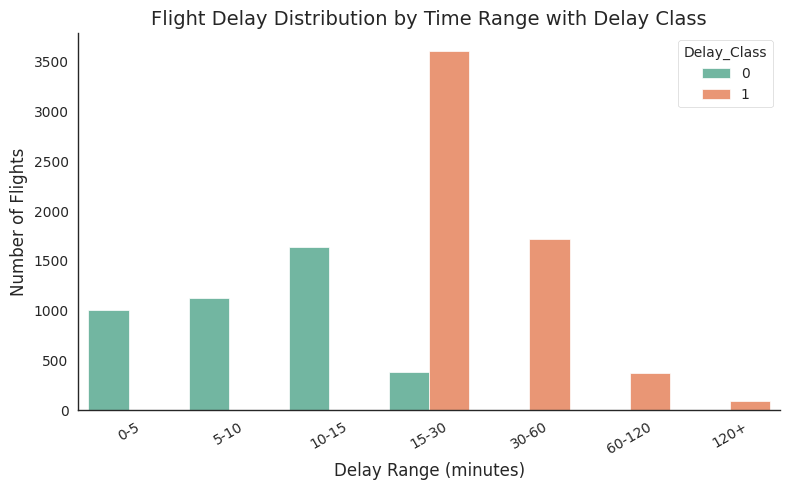

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df["Delay_Class"] = (df["average_delay_mins"] > 15).astype(int)

bins = [0, 5, 10, 15, 30, 60, 120, 200]
labels = ["0-5", "5-10", "10-15", "15-30", "30-60", "60-120", "120+"]

df["Delay_Bins"] = pd.cut(
    df["average_delay_mins"],
    bins=bins,
    labels=labels,
    right=False
)

sns.set_style("white")

plt.figure(figsize=(8,5))

sns.countplot(
    x="Delay_Bins",
    hue="Delay_Class",
    data=df,
    order=labels,
    palette="Set2"
)

plt.title("Flight Delay Distribution by Time Range with Delay Class", fontsize=14)
plt.xlabel("Delay Range (minutes)")
plt.ylabel("Number of Flights")

plt.xticks(rotation=30)

sns.despine()
plt.tight_layout()
plt.savefig("Cancellation Analysis.png",dpi = 300)
plt.show()

#### Correlation Analysis

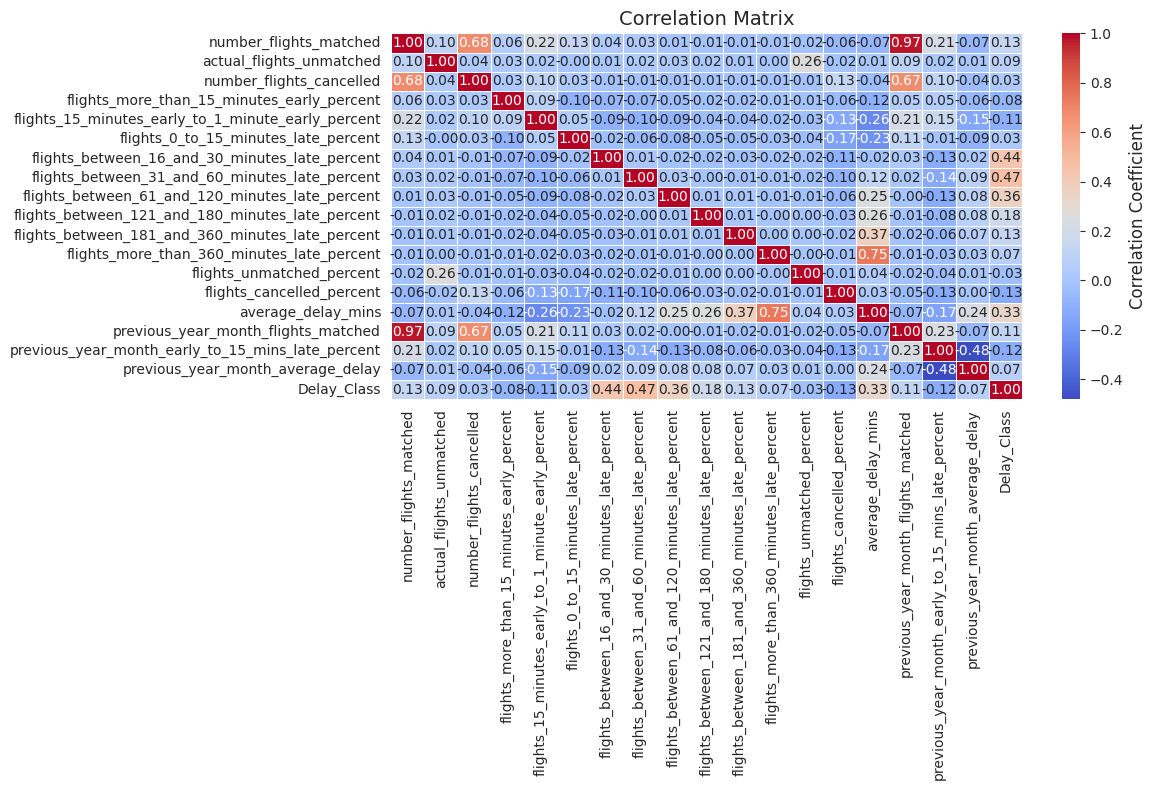

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df_corr = df.drop(columns=[df.columns[0], "reporting_period"], errors='ignore')


corr_matrix = df_corr.corr(numeric_only=True)

sns.set_style("white")

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Correlation Coefficient"}
)

plt.title("Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.savefig("Correlation_Analysis.png", dpi=300)
plt.show()

#### Compare With Previous Year

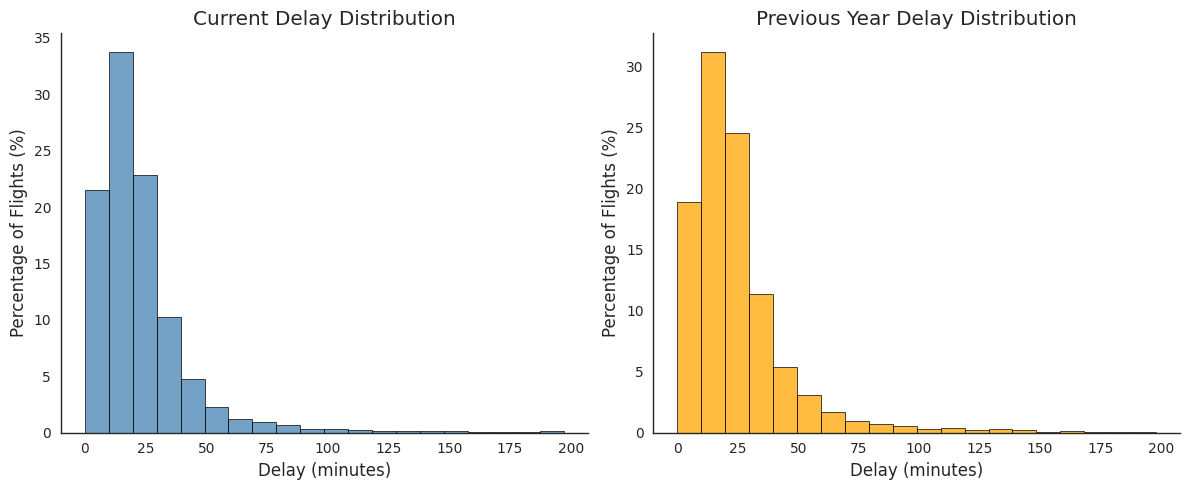

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

current = df["average_delay_mins"]
previous = df["previous_year_month_average_delay"]

current = current[current <= 200]
previous = previous[previous <= 200]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(current, bins=20, stat="percent", color="steelblue", edgecolor="black")
plt.title("Current Delay Distribution")
plt.xlabel("Delay (minutes)")
plt.ylabel("Percentage of Flights (%)")

plt.subplot(1,2,2)
sns.histplot(previous, bins=20, stat="percent", color="orange", edgecolor="black")
plt.title("Previous Year Delay Distribution")
plt.xlabel("Delay (minutes)")
plt.ylabel("Percentage of Flights (%)")

sns.despine()
plt.tight_layout()
plt.savefig("Compare With Previous Year.png", dpi=300)
plt.show()

### Create Target Variable

In [12]:
df["Delay_Class"] = df["average_delay_mins"].apply(lambda x: 1 if x > 15 else 0)

### Define Features & Target

In [13]:
X = df.drop(columns=[
    "average_delay_mins",
    "Delay_Class",
    "run_date"
])

y = df["Delay_Class"]

### Identify Column Types

In [14]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
print("Number of Categorical Columns:", len(categorical_cols))
print("Number of Numerical Columns:", len(numerical_cols))

print("\nNumerical Columns:")
print(numerical_cols)

Number of Categorical Columns: 6
Number of Numerical Columns: 18

Numerical Columns:
Index(['reporting_period', 'number_flights_matched',
       'actual_flights_unmatched', 'number_flights_cancelled',
       'flights_more_than_15_minutes_early_percent',
       'flights_15_minutes_early_to_1_minute_early_percent',
       'flights_0_to_15_minutes_late_percent',
       'flights_between_16_and_30_minutes_late_percent',
       'flights_between_31_and_60_minutes_late_percent',
       'flights_between_61_and_120_minutes_late_percent',
       'flights_between_121_and_180_minutes_late_percent',
       'flights_between_181_and_360_minutes_late_percent',
       'flights_more_than_360_minutes_late_percent',
       'flights_unmatched_percent', 'flights_cancelled_percent',
       'previous_year_month_flights_matched',
       'previous_year_month_early_to_15_mins_late_percent',
       'previous_year_month_average_delay'],
      dtype='object')


In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

### Create Preprocessing Pipeline

In [16]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

### Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Logistic Regression

In [18]:
model1 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000))
])

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Logistic Regression Accuracy:",

      accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Logistic Regression Accuracy: 0.9788705339992316
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1461
           1       0.99      0.97      0.98      1142

    accuracy                           0.98      2603
   macro avg       0.98      0.98      0.98      2603
weighted avg       0.98      0.98      0.98      2603



### Random Forest

In [19]:
model2 = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Random Forest Accuracy: 0.9665770265078756
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1461
           1       0.97      0.95      0.96      1142

    accuracy                           0.97      2603
   macro avg       0.97      0.97      0.97      2603
weighted avg       0.97      0.97      0.97      2603



### Hist Gradient Boosting

In [20]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, classification_report

to_dense = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)

model3 = Pipeline([
    ("preprocessing", preprocessor),
    ("to_dense", to_dense),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    ))
])


model3.fit(X_train, y_train)


y_pred3 = model3.predict(X_test)


print("XGBoost Accuracy:", accuracy_score(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

XGBoost Accuracy: 0.9757971571263926
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1461
           1       0.98      0.97      0.97      1142

    accuracy                           0.98      2603
   macro avg       0.98      0.98      0.98      2603
weighted avg       0.98      0.98      0.98      2603



### Compare All Models

In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest",
              "XGboost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.978871
1        Random Forest  0.966577
2              XGboost  0.975797


### ROC Comparision

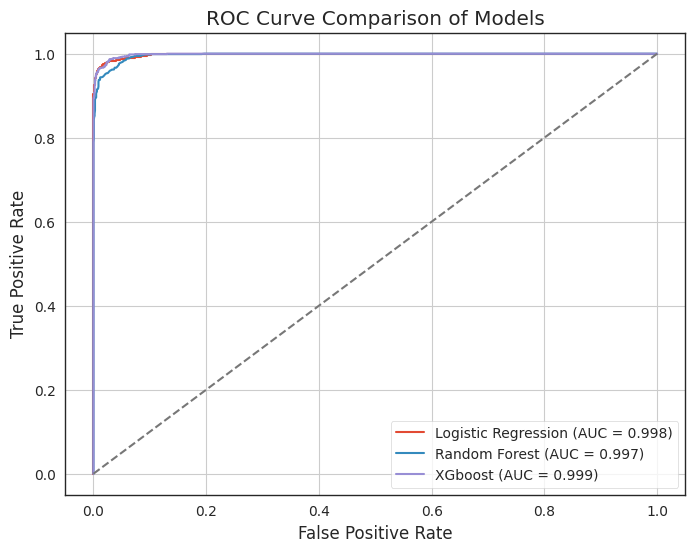

In [22]:
y_prob1 = model1.predict_proba(X_test)[:, 1]
y_prob2 = model2.predict_proba(X_test)[:, 1]
y_prob3 = model3.predict_proba(X_test)[:, 1]


fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
fpr3, tpr3, _ = roc_curve(y_test, y_prob3)


auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
auc3 = auc(fpr3, tpr3)


plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, label=f"Logistic Regression (AUC = {auc1:.3f})")
plt.plot(fpr2, tpr2, label=f"Random Forest (AUC = {auc2:.3f})")
plt.plot(fpr3, tpr3, label=f"XGboost (AUC = {auc3:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.grid()
plt.savefig("ROC Comparision.png",dpi = 300)
plt.show()

### Feature Importance Plot

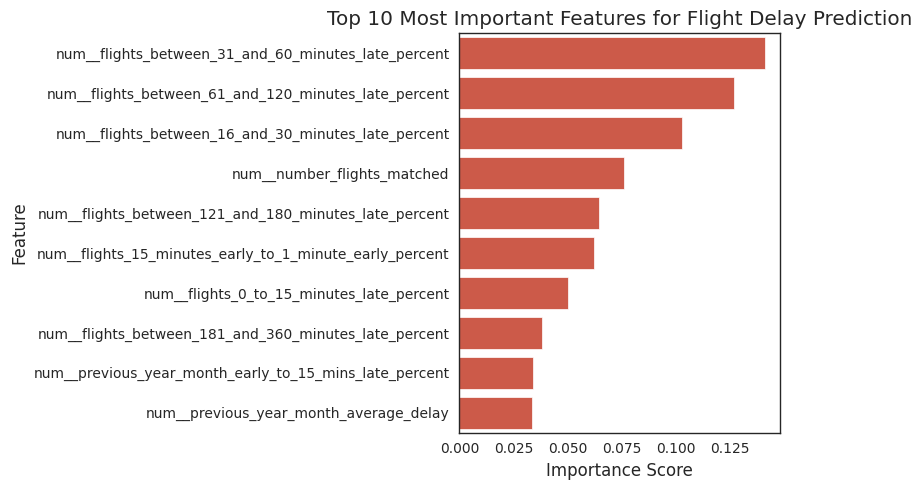

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = model2.named_steps["classifier"]


importances = rf_model.feature_importances_

feature_names = model2.named_steps["preprocessing"].get_feature_names_out()


feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(10)


plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)

plt.title("Top 10 Most Important Features for Flight Delay Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("Feature_Importance.png", dpi=300)
plt.show()

In [24]:
df["Delay_Class"].value_counts()

,count
Delay_Class,
0,7169
1,5844


In [25]:
from sklearn.model_selection import GridSearchCV

## Logistic Regression Hyperparameter Tuning

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


X_train = X_train.drop(columns=["Delay_Bins"], errors="ignore")
X_test = X_test.drop(columns=["Delay_Bins"], errors="ignore")


cat_cols = X_train.select_dtypes(include=["object", "category"]).columns
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns


num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=5000))
])


param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy")


grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)


print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Logistic Regression Hyperparameter Tuning", dpi=300)
plt.show()

## Random Forest Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

param_grid_rf = {
    "model__n_estimators":[100,200],
    "model__max_depth":[10,20,None]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring="accuracy")

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Best Parameters:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Random Forest Hyperparameter Tuning", dpi=300)
plt.show()

###  XG Boost Hyperparameter Tuning

In [ ]:
from xgboost import XGBClassifier

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(eval_metric="logloss"))
])

param_grid_xgb = {
    "model__n_estimators":[100,200],
    "model__learning_rate":[0.01,0.1],
    "model__max_depth":[3,6]
}

grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring="accuracy")

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("Best Parameters:", grid_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("XG Boost Hyperparameter Tuning", dpi=300)
plt.show()

### Final Comparison Table

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

print(results)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.savefig("Model Accuracy Comparison.png",dpi = 300)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))


y_prob_log = best_model.predict_proba(X_test)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.4f})")


y_prob_rf = best_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")

y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.4f})")

plt.plot([0,1],[0,1],'--')


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.savefig("Roc Curve Comparison",dpi = 300)
plt.legend()

plt.show()


print("Logistic Regression AUC:", auc_log)
print("Random Forest AUC:", auc_rf)
print("XGBoost AUC:", auc_xgb)